# CONFLUENCE Tutorial: Lumped Basin Workflow (East River)

This notebook walks through a complete workflow for a lumped basin model using the East River as an example. We'll execute each step individually to understand what's happening at each stage.

## Overview of This Tutorial

We'll work through the simplest case in catchment modeling: a lumped basin model. This treats the entire watershed as a single unit, making it an ideal starting point for understanding the CONFLUENCE workflow.

We'll run through:
1. Project setup and configuration
2. Domain definition (watershed delineation)
3. Data acquisition (forcings and attributes)
4. Model preprocessing
5. Model execution
6. Results visualization

## Setup and Import Libraries

In [1]:
import os
os.getcwd()
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [2]:
# Import required libraries
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import contextily as cx
import xarray as xr

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# Set up plotting style
plt.style.use('default')
%matplotlib inline

## Initialize CONFLUENCE
Now let's set up our directories and load the configuration. CONFLUENCE uses a centralized configuration file that controls all aspects of the modeling workflow.

In [3]:
# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data')  # ← User should modify this path

# Load and update configuration
config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_East_River.yaml'

# Read config file and update paths
with open(config_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update paths and settings 
config_dict['CONFLUENCE_CODE_DIR'] = str(CONFLUENCE_CODE_DIR)
config_dict['CONFLUENCE_DATA_DIR'] = str(CONFLUENCE_DATA_DIR)

# Update name and experiment id
config_dict['DOMAIN_NAME'] = 'East_River_lumped'
config_dict['EXPERIMENT_ID'] = 'tutorial_run'
config_dict['EXPERIMENT_TIME_START'] = '2000-01-02 01:00'
config_dict['EXPERIMENT_TIME_END'] = '2019-12-31 23:00'


config_dict['HYDROLOGICAL_MODEL'] = 'SUMMA'
config_dict['TAUDEM_DIR'] = '/home/dlhogan/tools/src/TauDEM/bin'

# Save updated config to a temporary file
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_notebook.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
# print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")


16:44:43 │ ============================================================
16:44:43 ● CONFLUENCE Logging Initialized
16:44:43 ● Domain: East_River_lumped
16:44:43 ● Experiment ID: tutorial_run
16:44:43 ● Log Level: INFO
16:44:43 ● Log File: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/_workLog_East_River_lumped/confluence_general_East_River_lumped_20250915_164443.log

16:44:43 │ ============================================================
16:44:43 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/_workLog_East_River_lumped/config_East_River_lumped_20250915_164443.yaml
16:44:43 ● Initializing CONFLUENCE system
16:44:43 ● Configuration loaded from: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_notebook.yaml
16:44:43 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
16:44:43 ● CONFLUENCE system initialized successfully
=== Directory Configuration ===
Code Directory: /home/dlhogan/

## 3. Project Setup - Organizing the Modeling Workflow
The first step in any CONFLUENCE workflow is to establish a well-organized project structure. This might seem trivial, but it's crucial for:

- Maintaining consistency across different experiments
- Ensuring all components can find required files
- Enabling reproducibility
- Facilitating collaboration

In [4]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

16:30:19 ● Setting up project for domain: East_River_lumped
16:30:19 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped
16:30:20 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/pour_point/East_River_lumped_pourPoint.shp

Created directories:
  📁 _workLog_East_River_lumped
  📁 attributes
  📁 forcing
  📁 observations
  📁 optimisation
  📁 plots
  📁 settings
  📁 shapefiles
  📁 simulations

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


## Geospatial Domain Definition and Analysis - Data acquisition 
Before we can delineate the watershed, we need elevation data. CONFLUENCE also acquires soil and land cover data at this stage for later use in the model.

In [5]:
# Acquire attributes
print("Acquiring geospatial attributes (DEM, soil, land cover)...")
# Check if we can reuse data from the default model
default_dem_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'attributes' / 'elevation' / 'dem'
default_forcing_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'forcing' / 'raw_data'
default_forcing_summa_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'forcing' / 'SUMMA_input'
default_catchment_intersection_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'shapefiles' / 'catchment_intersection'
can_reuse = default_dem_path.exists()
can_reuse_forcing = default_forcing_path.exists()
can_reuse_forcing_summa = default_forcing_summa_path.exists()
can_reuse_catchment_intersection = default_catchment_intersection_path.exists()

if can_reuse or can_reuse_forcing or can_reuse_forcing_summa or can_reuse_catchment_intersection:
    import shutil
    
    # Create a function to copy files with name substitution
    def copy_with_name_substitution(src_path, dst_path, old_str='', new_str=''):
        if not src_path.exists():
            return False
            
        # Create destination directory if it doesn't exist
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        if src_path.is_dir():
            # Copy entire directory
            if not dst_path.exists():
                dst_path.mkdir(parents=True, exist_ok=True)
                
            # Copy all files with name substitution
            for src_file in src_path.glob('**/*'):
                if src_file.is_file():
                    # Create relative path
                    rel_path = src_file.relative_to(src_path)
                    # Create new filename with substitution
                    new_name = src_file.name.replace(old_str, new_str)
                    # Create destination path
                    dst_file = dst_path / rel_path.parent / new_name
                    # Create parent directories if they don't exist
                    dst_file.parent.mkdir(parents=True, exist_ok=True)
                    # Copy the file
                    shutil.copy2(src_file, dst_file)
            return True
        elif src_path.is_file():
            # Copy single file with name substitution
            new_name = dst_path.name.replace(old_str, new_str)
            dst_file = dst_path.parent / new_name
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_file)
            return True
        
        return False

    print("Found existing geospatial data from default model. Copying and renaming files...")
    
    # Copy and rename DEM and other attribute data
    if can_reuse:
        # Define paths
        src_attr_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'attributes'
        dst_attr_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'attributes'
        
        # Copy attributes with name substitution
        copied = copy_with_name_substitution(src_attr_path, dst_attr_path, 'domain_butte_snotel', 'domain_East_River_lumped')
        if copied:
            print("✓ Copied and renamed attribute files from default model")
    
    # Copy and rename forcing data
    if can_reuse_forcing:
        # Define paths
        src_forcing_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'forcing' / 'raw_data'
        dst_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'forcing' / 'raw_data'
         
        # Copy forcing data with name substitution
        copied = copy_with_name_substitution(src_forcing_path, dst_forcing_path, 'domain_butte_snotel', 'domain_East_River_lumped')
        if copied:
            print("✓ Copied and renamed forcing data from default model")
    
    # Copy and rename SUMMA input files
    if can_reuse_forcing_summa:
        # Define paths
        src_forcing_summa_path = CONFLUENCE_DATA_DIR / 'domain_butte_snotel' / 'forcing' / 'SUMMA_input'
        dst_forcing_summa_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'forcing' / 'SUMMA_input'

        # Copy forcing data with name substitution
        copied = copy_with_name_substitution(src_forcing_summa_path, dst_forcing_summa_path, 'butte_snotel', 'East_River_lumped')
        if copied:
            print("✓ Copied and renamed SUMMA input files from default model")

    # Copy and rename catchment intersection files
    if can_reuse_catchment_intersection:
        # Define paths
        src_catchment_intersection_path = default_catchment_intersection_path
        dst_catchment_intersection_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'shapefiles' / 'catchment_intersection'

        # Copy catchment intersection files with name substitution
        copied = copy_with_name_substitution(src_catchment_intersection_path, dst_catchment_intersection_path, 'butte_snotel', 'East_River_lumped')
        if copied:
            print("✓ Copied and renamed catchment intersection files from default model")

    print("The lumped model will use these copied files as a starting point.")
else:
    print("No existing data found from the default model. Will acquire all data from scratch.")

    # Step 2: Geospatial Domain Definition - Data Acquisition
    print("\n=== Step 2: Geospatial Domain Definition - Data Acquisition ===")
    
    # Acquire attributes
    print("Acquiring geospatial attributes (DEM, soil, land cover)...")
    confluence.managers['data'].acquire_attributes()

    # Acquire forcings
    print(f"\nAcquiring forcing data: {confluence.config['FORCING_DATASET']}")
    confluence.managers['data'].acquire_forcings()
    
print("\n✓ Geospatial attributes acquired")

Acquiring geospatial attributes (DEM, soil, land cover)...
Found existing geospatial data from default model. Copying and renaming files...
✓ Copied and renamed attribute files from default model
✓ Copied and renamed forcing data from default model
✓ Copied and renamed SUMMA input files from default model
✓ Copied and renamed catchment intersection files from default model
The lumped model will use these copied files as a starting point.

✓ Geospatial attributes acquired


## Geospatial Domain Definition and Analysis - Delineation 

In [6]:
# Define domain
print(f"\nDelineating watershed using method: {confluence.config['DOMAIN_DEFINITION_METHOD']}")
watershed_path = confluence.managers['domain'].define_domain()

# Check outputs
print("\nDomain definition complete:")
print(f"  - Watershed defined: {watershed_path is not None}")


Delineating watershed using method: lumped
17:26:41 ● Domain definition workflow starting with: lumped
17:26:41 ● Starting lumped watershed delineation for East_River_lumped
PitRemove version 5.3.9


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif has geographic coordinate system.
Nodata value input to create partition from file: -9999.000000
Nodata value recast to float used in partition raster: -9999.000000


This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.


Processes: 4
Header read time: 0.313145
Data read time: 0.014869
Compute time: 0.125123
Write time: 0.055295
Total time: 0.508433
17:26:43 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/fel.tif
D8FlowDir version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/fel.tif has geographic coordinate system.
Nodata value input to create partition from file: -300000000549775575777803994281145270272.000000
Nodata value recast to float used in partition raster: -300000000549775575777803994281145270272.000000


...

Gage Watershed version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Size: 4
Read time: 0.058087
Compute time: 0.015347
Write time: 0.009210
Total time: 0.082644
17:26:47 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/gagewatershed -p /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/p.tif -o /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/om.shp -gw /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/watershed.tif -id /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/watershed_id.txt


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

17:26:47 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped_temp.shx
17:26:47 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped_temp.shp
17:26:47 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped_temp.dbf
17:26:47 ● Filtered watershed shapefile created at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped.shp
17:26:47 ● Updated watershed shapefile at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped.shp
17:26:47 ● Cleaned up intermediate files: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir
17:26:47 ● Created river network shapefile at

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.45506608 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.45506608 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


17:26:48 ● Domain map saved to /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/domain/domain_map.png
17:26:48 ● Domain definition workflow finished

Domain definition complete:
  - Watershed defined: True


## Geospatial Domain Definition and Analysis - Discretisation 

In [7]:
# Discretize domain
print(f"\nCreating HRUs using method: {confluence.config['DOMAIN_DISCRETIZATION']}")
hru_path = confluence.managers['domain'].discretize_domain()

# Check outputs
print("\nDomain definition complete:")
print(f"  - HRUs created: {hru_path is not None}")


Creating HRUs using method: GRUs
17:26:57 ● Discretizing domain using method: GRUs
17:26:57 ● Starting domain discretization using attributes: ['GRUs']

17:26:57 │ Step 1/2: Running single attribute discretization method
17:26:57 ● config domain name East_River_lumped
17:26:57 ● Calculating mean elevation for each HRU
17:26:57 ● DEM CRS: EPSG:4326
17:26:57 ● Shapefile CRS: EPSG:4326
17:26:57 ● CRS match - no reprojection needed
17:26:57 ● Successfully calculated elevation statistics for 1 HRUs
17:26:57 ● Calculated centroids in WGS84: lat range 38.876597 to 38.876597, lon range -106.924168 to -106.924168
17:26:57 ● GRUs saved as HRUs to /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.45506608 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.45506608 of field HRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


17:26:58 ● HRU plot saved to /scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/catchment/East_River_lumped_HRUs_as_GRUs.png

17:26:58 │ Step 2/2: Sorting catchment shape
17:26:58 ● Sorting catchment shape
17:26:58 ● Catchment shape sorted and saved to /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp
17:26:58 ● Domain discretization completed in 1.31 seconds
17:26:58 ● Domain discretization failed - no shapefile created

Domain definition complete:
  - HRUs created: False


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.45506608 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.45506608 of field HRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


## Visualize the Delineated Domain
Let's see what our watershed looks like:

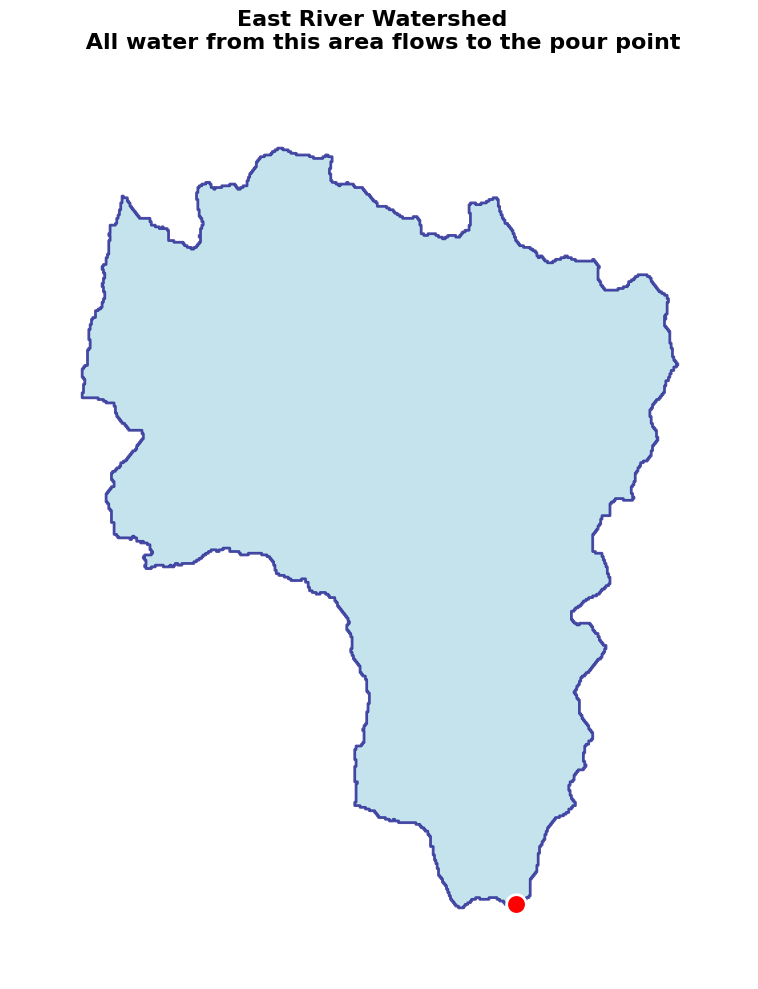

In [8]:
# Visualize the watershed
basin_path = project_dir / 'shapefiles' / 'river_basins'
if basin_path.exists():
    basin_files = list(basin_path.glob('*.shp'))
    
    if basin_files:
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Load watershed and pour point
        basin_gdf = gpd.read_file(basin_files[0])
        pour_point_gdf = gpd.read_file(pour_point_path)
        
        # Reproject for visualization
        basin_web = basin_gdf.to_crs(epsg=3857)
        pour_web = pour_point_gdf.to_crs(epsg=3857)
        
        # Plot watershed
        basin_web.plot(ax=ax, facecolor='lightblue', edgecolor='navy', 
                       linewidth=2, alpha=0.7)
        
        # Add pour point
        pour_web.plot(ax=ax, color='red', markersize=200, marker='o', 
                      edgecolor='white', linewidth=2, zorder=5)
                
        # Set extent
        minx, miny, maxx, maxy = basin_web.total_bounds
        pad = 5000
        ax.set_xlim(minx - pad, maxx + pad)
        ax.set_ylim(miny - pad, maxy + pad)
        
        ax.set_title('East River Watershed  \n All water from this area flows to the pour point', 
                    fontsize=16, fontweight='bold', pad=20)
        
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## Model Agnostic Data Pre-Processing - Observed data
For a lumped model, the entire watershed becomes a single Hydrologic Response Unit (HRU). This simplification assumes uniform characteristics across the watershed - obviously an approximation, but useful for many applications.


In [27]:
# Model Agnostic Data Pre-Processing
print("Processing observed streamflow data...")
confluence.managers['data'].process_observed_data()

Processing observed streamflow data...
17:01:57 ● Processing observed data
17:01:57 ● Processing USGS streamflow data directly from API
17:01:57 ● Retrieving discharge data for station 09112500
17:01:57 ● Time period: 2000-01-02 to 2025-08-19
17:01:57 ● Converting from cfs to cms using factor: 0.0283168
17:01:57 ● Using formatted start date: 2000-01-02
17:01:57 ● Using formatted end date: 2025-08-19
17:01:57 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=09112500&format=rdb&parameterCd=00060&startDT=2000-01-02&endDT=2025-08-19
17:02:27 ● Error fetching data from USGS API: HTTPSConnectionPool(host='nwis.waterservices.usgs.gov', port=443): Read timed out. (read timeout=30)
17:02:27 ● Trying fallback URL: https://waterservices.usgs.gov/nwis/dv/?site=09112500&format=rdb&parameterCd=00060&startDT=2000-01-02&endDT=2025-08-19
17:02:30 ● Processed streamflow data saved to: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/E

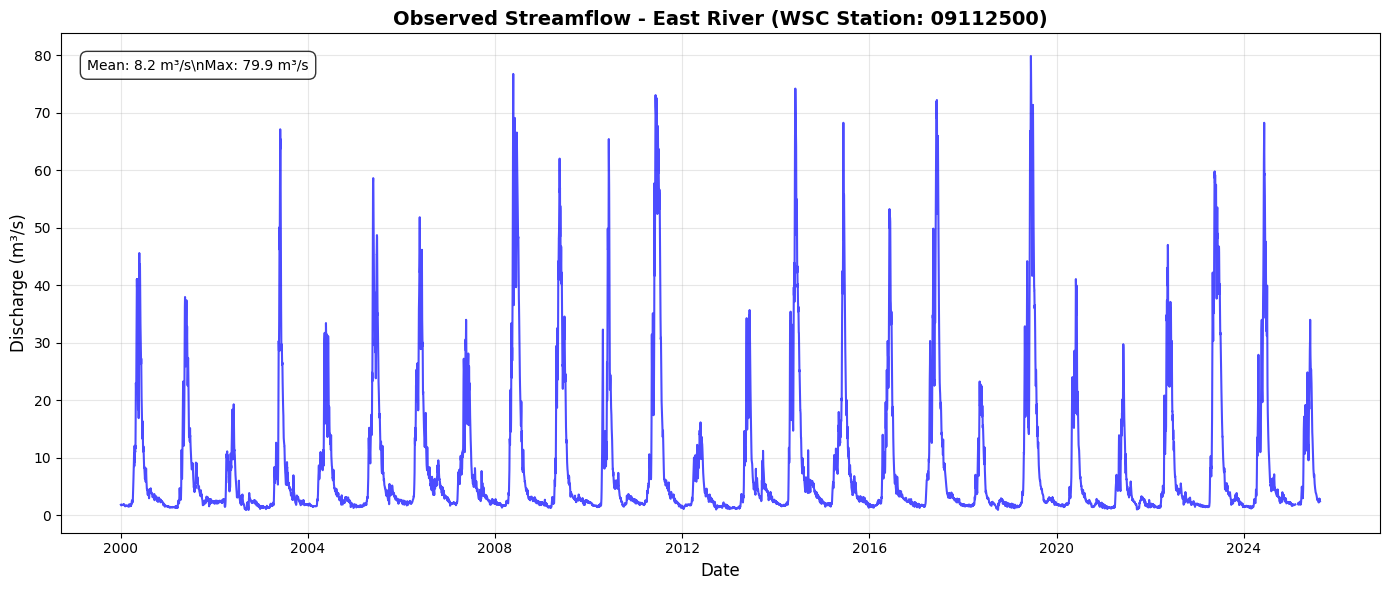

In [9]:
# Visualize observed streamflow data
obs_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'observations' / 'streamflow' / 'preprocessed' / f"{confluence.config['DOMAIN_NAME']}_streamflow_processed.csv"
if obs_path.exists():
    obs_df = pd.read_csv(obs_path)
    obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(obs_df['datetime'], obs_df['discharge_cms'], 
            linewidth=1.5, color='blue', alpha=0.7)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Discharge (m³/s)', fontsize=12)
    ax.set_title(f'Observed Streamflow - East River (WSC Station: {confluence.config["STATION_ID"]})', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    ax.text(0.02, 0.95, f'Mean: {obs_df["discharge_cms"].mean():.1f} m³/s\\nMax: {obs_df["discharge_cms"].max():.1f} m³/s', 
            transform=ax.transAxes, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

## 9. Model Agnostic Data Pre-Processing - Forcing data

In [10]:
# Acquire forcings
print(f"\nAcquiring forcing data: {confluence.config['FORCING_DATASET']}")
#confluence.managers['data'].acquire_forcings()


Acquiring forcing data: ERA5


## 10. Model Agnostic Data Pre-Processing - Remapping and zonal statistics

In [11]:
# Run model-agnostic preprocessing
print("\nRunning model-agnostic preprocessing...")
# confluence.managers['data'].run_model_agnostic_preprocessing()


Running model-agnostic preprocessing...


## Model-Specific Preprocessing
Now we prepare inputs specific to our chosen hydrological model (SUMMA in this case). Each model has its own requirements for input format and configuration.

In [34]:
# Model Specific Processing 
print(f"Preparing {confluence.config['HYDROLOGICAL_MODEL']} input files...")
confluence.managers['model'].preprocess_models()

Preparing SUMMA input files...
17:12:26 ● Starting model-specific preprocessing
17:12:26 ● Processing model: SUMMA
17:12:26 ● Starting SUMMA spatial preprocessing
17:12:26 ● Starting memory-efficient temperature lapse rate and data step application
17:12:26 ● Loading topology data...
17:12:26 ● Loaded topology data: 25 rows, 0.02 MB
17:12:26 ● Found 468 forcing files to process
17:12:26 ● Pre-calculating lapse rate corrections...
17:12:27 ● Prepared lapse corrections for 1 HRUs
17:12:27 ● Processing files in batches of 100
17:13:10 ● Completed processing of 468 ERA5 forcing files with temperature lapsing
17:13:10 ● Copying SUMMA base settings
17:13:10 ● SUMMA base settings copied to /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA
17:13:10 ● Creating SUMMA file manager
17:13:10 ● SUMMA file manager created at /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/fileManager.txt
17:13:10 ● Creating forcing file list
17:13:10 ● Found 468 ERA5 

## Model Instantiation

In [4]:
# Run models
print(f"\nRunning {confluence.config['HYDROLOGICAL_MODEL']} model...")
confluence.managers['model'].run_models()

print("\nModel run complete")


Running SUMMA model...
16:44:52 ● Starting model runs
16:44:52 ● Running model: SUMMA
16:44:52 ● Starting SUMMA run
16:52:45 ● SUMMA run completed successfully
16:52:45 ● SUMMA model run completed successfully
16:52:45 ● Starting model output visualisation
16:52:45 ● Using lumped SUMMA output for visualization
16:52:45 ● Converted runoff from m/s to m³/s using basin area: 748251731.4550661 m²
16:52:45 ● Skipping first 730 days (10.0% of total period) as spinup
16:52:45 ● Using data from 2002-01-01 00:59:59.999986560 to 2019-12-31 23:00:00.000013312
16:52:48 ● Model runs completed

Model run complete


## Visualisation of results

Let's see how our streamflow hydrograph looks for the default instantiation sof SUMMA

In [5]:
# Visualize Observed vs. Simulated Streamflow
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import matplotlib.dates as mdates
import geopandas as gpd
from pathlib import Path

# 1. Load the observed streamflow data - using lumped case approach
obs_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'observations' / 'streamflow' / 'preprocessed' / f"{confluence.config['DOMAIN_NAME']}_streamflow_processed.csv"
if not obs_path.exists():
    print(f"Warning: Observed streamflow data not found at {obs_path}")
    print("Checking for alternative locations...")
    alt_paths = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(f"**/observations/streamflow/preprocessed/*_streamflow_processed.csv"))
    if alt_paths:
        obs_path = alt_paths[0]
        print(f"Found alternative streamflow data at: {obs_path}")
    else:
        print("No observed streamflow data found. Only simulated data will be displayed.")

# 2. Load the simulated streamflow data from SUMMA output - using lumped case approach
sim_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA" / f"{config_dict['EXPERIMENT_ID']}_timestep.nc"

# Check for alternative NetCDF file patterns if not found
if not sim_path.exists():
    print(f"Simulated data not found at {sim_path}")
    print("Checking for alternative NetCDF files...")
    alt_sim_paths = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(
        f"domain_{config_dict['DOMAIN_NAME']}/simulations/{config_dict['EXPERIMENT_ID']}/SUMMA/*.nc"))
    
    if alt_sim_paths:
        sim_path = alt_sim_paths[0]
        print(f"Found alternative simulation data at: {sim_path}")
    else:
        raise FileNotFoundError(f"No simulation results found for experiment {config_dict['EXPERIMENT_ID']}")

# Load simulated data
print(f"Loading simulated data from: {sim_path}")
ds = xr.open_dataset(sim_path)

# Extract averageRoutedRunoff
print("Extracting 'averageRoutedRunoff' variable...")
if 'averageRoutedRunoff' in ds:
    # Extract and convert to DataFrame
    sim_runoff = ds['averageRoutedRunoff'].to_dataframe().reset_index()
    
    # Get catchment area from the river basin shapefile to convert from m/s to m³/s
    basin_shapefile = config_dict.get('RIVER_BASINS_NAME', 'default')
    if basin_shapefile == 'default':
        basin_shapefile = f"{config_dict['DOMAIN_NAME']}_riverBasins_{config_dict.get('DOMAIN_DEFINITION_METHOD', 'lumped')}.shp"
    
    basin_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "shapefiles" / "river_basins" / basin_shapefile
    
    try:
        print(f"Loading catchment shapefile from: {basin_path}")
        basin_gdf = gpd.read_file(basin_path)
        area_col = config_dict.get('RIVER_BASIN_SHP_AREA', 'GRU_area')
        
        # Area should be in m²
        if area_col in basin_gdf.columns:
            area_m2 = basin_gdf[area_col].sum()
            print(f"Catchment area: {area_m2:.2f} m² ({area_m2/1e6:.2f} km²)")
            
            # Convert from m/s to m³/s by multiplying by area in m²
            # Assuming first GRU for lumped basin simulation if multiple GRUs exist
            if 'gru' in sim_runoff.columns:
                sim_runoff = sim_runoff[sim_runoff['gru'] == 1][['time', 'averageRoutedRunoff']]
            else:
                sim_runoff = sim_runoff[['time', 'averageRoutedRunoff']]
            
            # Convert units: m/s -> m³/s
            sim_runoff['discharge_cms'] = sim_runoff['averageRoutedRunoff'] * area_m2
            print(f"Converted runoff from m/s to m³/s (multiplied by basin area)")
        else:
            print(f"Warning: Area column '{area_col}' not found in catchment shapefile")
            sim_runoff['discharge_cms'] = sim_runoff['averageRoutedRunoff']  # Use raw values as fallback
    except Exception as e:
        print(f"Error getting basin area: {str(e)}. Using raw values.")
        sim_runoff['discharge_cms'] = sim_runoff['averageRoutedRunoff']  # Use raw values as fallback
    
    # Set index to time for easier processing
    sim_runoff.set_index('time', inplace=True)
    sim_df = sim_runoff[['discharge_cms']]
else:
    print("Warning: 'averageRoutedRunoff' variable not found in the SUMMA output")
    print("Available variables:", list(ds.data_vars))
    raise ValueError("Required 'averageRoutedRunoff' variable not found in SUMMA output")

# Load observed data
obs_df = None
if obs_path.exists():
    print(f"Loading observed streamflow data from: {obs_path}")
    obs_df = pd.read_csv(obs_path)
    obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])
    obs_df.set_index('datetime', inplace=True)
    print(f"Observed data period: {obs_df.index.min()} to {obs_df.index.max()}")
    print(f"Observed streamflow range: {obs_df['discharge_cms'].min():.2f} to {obs_df['discharge_cms'].max():.2f} m³/s")

# Show simulated data info
print(f"Simulated data period: {sim_df.index.min()} to {sim_df.index.max()}")
print(f"Simulated streamflow range: {sim_df['discharge_cms'].min():.2f} to {sim_df['discharge_cms'].max():.2f} m³/s")



Loading simulated data from: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/tutorial_run/SUMMA/tutorial_run_timestep.nc
Extracting 'averageRoutedRunoff' variable...
Loading catchment shapefile from: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped.shp
Catchment area: 748251731.46 m² (748.25 km²)
Converted runoff from m/s to m³/s (multiplied by basin area)
Loading observed streamflow data from: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv
Observed data period: 2000-01-02 00:00:00 to 2025-08-19 00:00:00
Observed streamflow range: 0.90 to 79.85 m³/s
Simulated data period: 2000-01-02 00:59:59.999986560 to 2019-12-31 23:00:00.000013312
Simulated streamflow range: 0.01 to 251.20 m³/s



📈 Semi-Distributed Performance Metrics:
   📊 RMSE: 12.18 m³/s
   📊 Bias: -1.64 m³/s (-19.9%)
   📊 MAE: 6.31 m³/s
   📊 Correlation (r): 0.509
   📊 Nash-Sutcliffe (NSE): 0.020
   📊 Kling-Gupta (KGE): 0.470

📊 Flow Regime Assessment:
   High flows (Q95): Obs=36.2, Sim=14.9 m³/s (-58.7%)
   Medium flows (Q50): Obs=3.0, Sim=3.9 m³/s (+29.0%)
   Low flows (Q05): Obs=1.4, Sim=1.5 m³/s (+1.3%)

📈 Creating semi-distributed evaluation visualization...


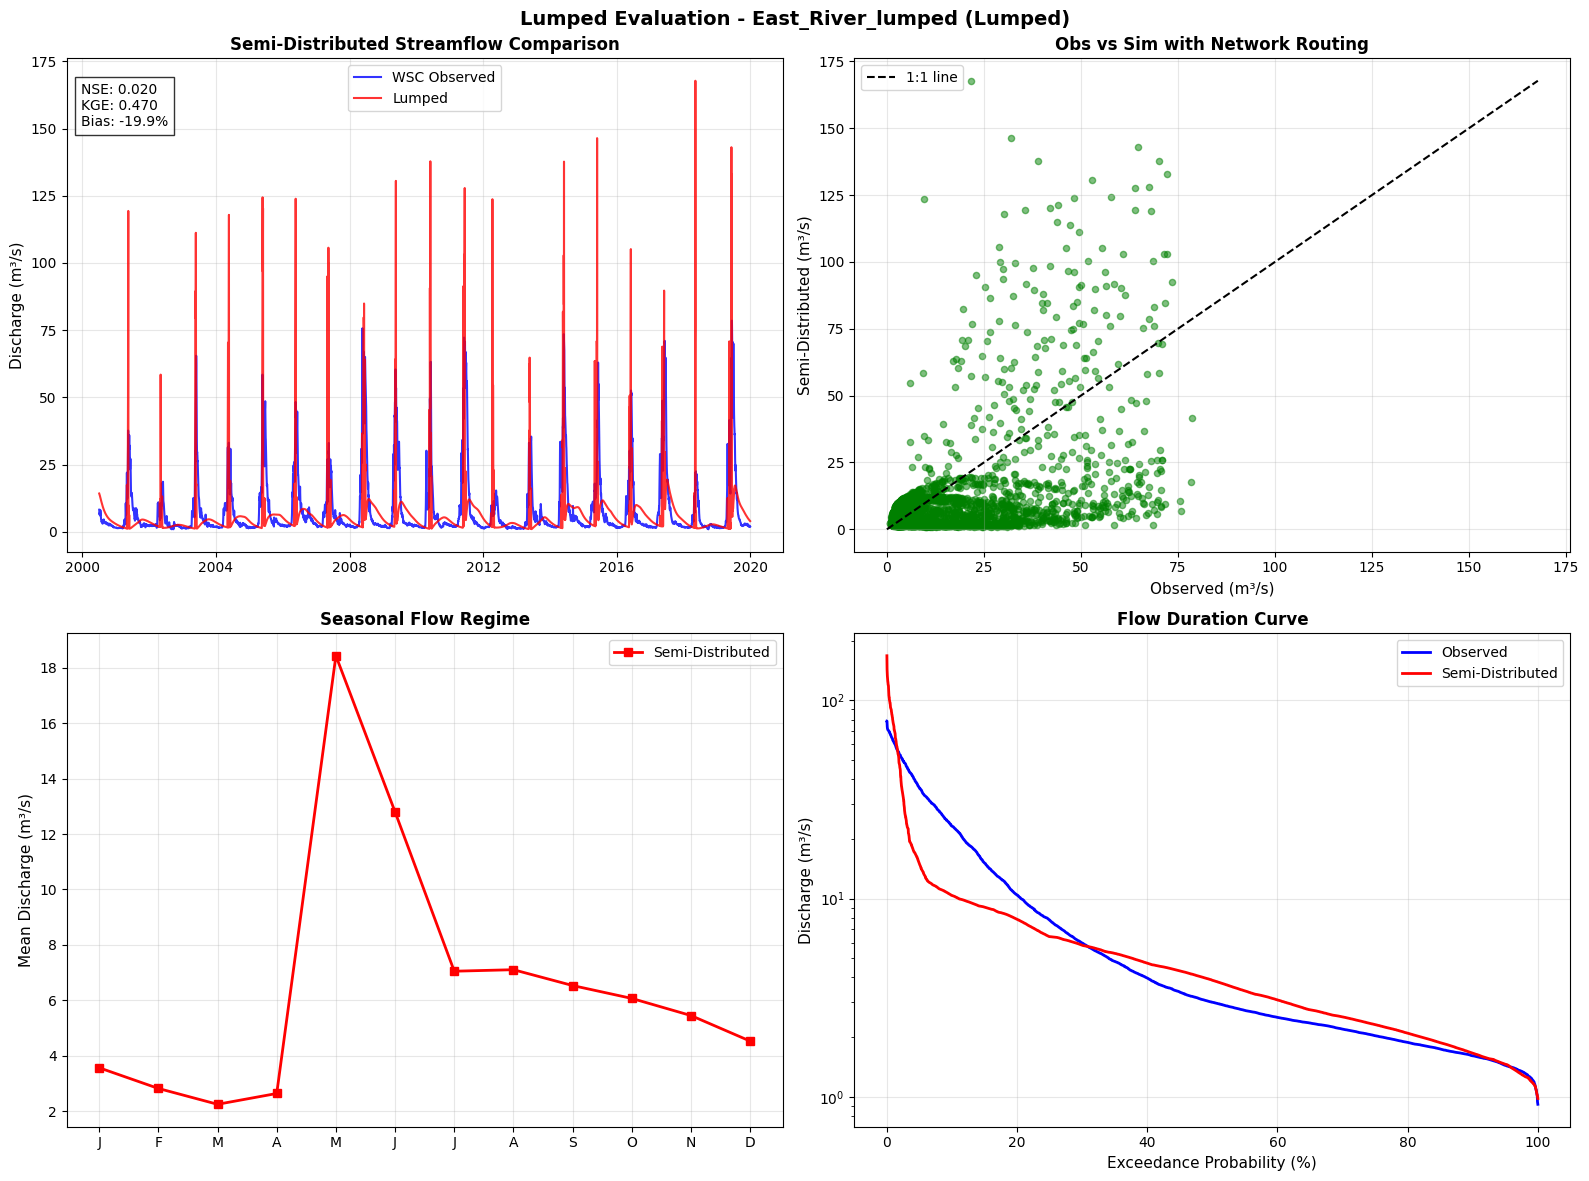

In [7]:

# =============================================================================
# Lumped PERFORMANCE ASSESSMENT
# =============================================================================
    
# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

# Resample to daily and filter to common period
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]

# Remove NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]

# Calculate comprehensive performance metrics
print(f"\n📈 Semi-Distributed Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()
pbias = 100 * bias / obs_valid.mean()

# Efficiency metrics
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# =============================================================================
# ROUTING AND SPATIAL EFFECTS ANALYSIS
# =============================================================================

# Analyze peak flow timing (routing delay effects)
obs_peaks = obs_valid[obs_valid > obs_valid.quantile(0.95)]
sim_peaks = sim_valid[sim_valid > sim_valid.quantile(0.95)]

if len(obs_peaks) > 0 and len(sim_peaks) > 0:
    # Find largest peak in common period
    obs_max_date = obs_valid.idxmax()
    sim_max_date = sim_valid.idxmax()
    peak_timing_diff = (sim_max_date - obs_max_date).days
    
# Flow regime analysis
flow_stats = {
    'High flows (Q95)': (obs_valid.quantile(0.95), sim_valid.quantile(0.95)),
    'Medium flows (Q50)': (obs_valid.quantile(0.50), sim_valid.quantile(0.50)),
    'Low flows (Q05)': (obs_valid.quantile(0.05), sim_valid.quantile(0.05))
}

print(f"\n📊 Flow Regime Assessment:")
for regime, (obs_q, sim_q) in flow_stats.items():
    bias_pct = 100 * (sim_q - obs_q) / obs_q
    print(f"   {regime}: Obs={obs_q:.1f}, Sim={sim_q:.1f} m³/s ({bias_pct:+.1f}%)")

# =============================================================================
# COMPREHENSIVE SEMI-DISTRIBUTED VISUALIZATION
# =============================================================================

print(f"\n📈 Creating semi-distributed evaluation visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-',
         label='WSC Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-',
         label=f'Lumped', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Semi-Distributed Streamflow Comparison', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
# ax1.set_xlim([datetime(2018, 1, 1), datetime(2019, 12, 31)])

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot with routing emphasis (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='green', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Semi-Distributed (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim with Network Routing', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
# monthly_obs = obs_valid.groupby(obs_valid.index.month).mean()
monthly_sim = sim_valid.groupby(sim_valid.index.month).mean()
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# ax3.plot(months, monthly_obs.values, 'o-', label='Observed',
#          color='blue', linewidth=2, markersize=6)
ax3.plot(months, monthly_sim.values, 's-', label='Semi-Distributed',
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Semi-Distributed', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Lumped Evaluation - {config_dict["DOMAIN_NAME"]} (Lumped)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Optional Steps - Optimization and Analysis

In [ ]:
# Step 5 & 6: Optional Steps (Optimization and Analysis)
print("=== Step 5 & 6: Optional Steps ===")


## Alternative - Run Complete Workflow

In [ ]:
# Alternative: Run the complete workflow in one step
# (Uncomment to use this instead of the step-by-step approach)

# confluence.run_workflow()

## Summary: Understanding the CONFLUENCE Workflow
Congratulations! You've completed a full lumped basin modeling workflow with CONFLUENCE. 
